# CH-SW Fit

Long-range CH-driven solar-wind propagation notebook for fitting workflows using sparse-phi propagation.

This notebook propagates from `2010-01-01` through the end of `2024` with `phi_targets = [0.0]`.

It uses the standard ballistic solver on a sparse phi axis, so the `phi=0` slice matches the full propagation at the same cadence and model settings.

For long-range fitting throughput, `superresolution_enabled_override` is set to `False` by default here. Set it to `None` to match `Config/SW/Ballistic.json` exactly.

In [245]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [246]:
import gc
import os
import sys
import threading
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import get_context
from pathlib import Path
from tqdm import tqdm

os.environ.setdefault("MPLCONFIGDIR", "/tmp/helio_n_matplotlib")

cwd = Path.cwd().resolve()
project_root = None
for candidate in (cwd, *cwd.parents, Path("/home/smdc/helio-n")):
    if (candidate / "Library").exists() and (candidate / "Config").exists():
        project_root = candidate
        break
assert (
    project_root is not None
), "Could not locate the helio-n project root for notebook imports."
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from scipy.optimize import curve_fit

from Library.ICME import drop_icme_periods

from Library.SW.Ballistic import postprocess_max_field, propagate_phi_targets
from Library.SW.Config import (
    EmpiricalSpec,
    load_ballistic_spec,
    load_empirical_spec,
    load_sw_runtime_spec,
    resolve_time_controls,
)
from Library.SW.Coords import compute_rotation_state
from Library.SW.Inputs import (
    build_forecast_earth_frame,
    build_model_input_series,
    load_ace_at_earth,
    load_sw_input_frame,
    load_sw_input_from_sql,
)


In [247]:
start_dt = pd.Timestamp("2018-01-01")
end_dt = pd.Timestamp("2024-03-31")
input_source = "sql"
# input_parquet_path = "Data/CH Area.parquet"
phi_targets = [0.0]
superresolution_enabled_override = True
show_progress = True

print("start_dt:", start_dt)
print("end_dt:", end_dt)
print("phi_targets:", phi_targets)
print("superresolution_enabled_override:", superresolution_enabled_override)


def memory_used_gb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024**3

start_dt: 2018-01-01 00:00:00
end_dt: 2024-03-31 00:00:00
phi_targets: [0.0]
superresolution_enabled_override: True


In [248]:
empirical_defaults = load_empirical_spec()
empirical_defaults

EmpiricalSpec(json_path=PosixPath('/home/smdc/helio-n/Config/SW/Empirical.json'), slow_sw_speed=350.0, a=180.0, alpha=0.6)

In [249]:
ballistic = load_ballistic_spec()
runtime = load_sw_runtime_spec()
time_controls = resolve_time_controls(
    ballistic,
    superresolution_enabled_override=superresolution_enabled_override,
)

df_sdo_sw = load_sw_input_frame(
    start_dt=start_dt,
    end_dt=end_dt,
    source=input_source,
    # input_parquet_path=input_parquet_path,
)

In [250]:
def run_sparse_phi_propagation(
    sdo_input_df,
    ballistic,
    runtime,
    time_controls,
    phi_targets,
    slow_sw_speed=300.0,
    a=180.0,
    alpha=0.6,
    show_progress=True,
):
    empirical = EmpiricalSpec(
        json_path=project_root / "Config" / "SW" / "Empirical.json",
        slow_sw_speed=float(slow_sw_speed),
        a=float(a),
        alpha=float(alpha),
    )

    prepared = build_model_input_series(
        sdo_input_df=sdo_input_df,
        empirical=empirical,
        time_controls=time_controls,
        simulation_pad_days=ballistic.simulation_pad_days,
    )
    rotation = compute_rotation_state(
        cr_days=ballistic.cr_days,
        phi_step_minutes=ballistic.phi_step_minutes,
    )
    df_v_run = (
        prepared["df_v"]
        .loc[
            (prepared["df_v"].index >= prepared["sim_start"])
            & (prepared["df_v"].index <= prepared["sim_end"])
        ]
        .copy()
    )

    phi_run = propagate_phi_targets(
        df_v_run=df_v_run,
        sim_start=prepared["sim_start"],
        sim_end=prepared["sim_end"],
        time_freq=time_controls.time_freq,
        rotation_state=rotation,
        r0=ballistic.r0,
        r_max=ballistic.r_max,
        dense_memory_budget_gb=runtime.dense_memory_budget_gb,
        memory_guard_enabled=ballistic.memory_guard_enabled,
        horizon_hours=ballistic.horizon_hours,
        time_step_hours=time_controls.time_step_hours,
        field_half_width_h=ballistic.field_half_width_h,
        r_solar_km=ballistic.r_solar_km,
        use_swept_cell=ballistic.use_swept_cell,
        use_cr_reset=ballistic.use_cr_reset,
        max_seed_batch=runtime.max_seed_batch,
        phi_targets=phi_targets,
        show_progress=show_progress,
    )

    post = postprocess_max_field(
        V_accum_max=phi_run.accumulators.V_accum_max,
        slow_sw_speed=empirical.slow_sw_speed,
        post_chunk_t=runtime.post_chunk_t,
        show_progress=show_progress,
    )

    earth_r_idx = int(np.argmin(np.abs(phi_run.grid.r_axis - ballistic.earth_r_target)))
    propagated_earth = pd.Series(
        post.V_grid[:, 0, earth_r_idx],
        index=phi_run.grid.time_axis,
        name="v_model_earth_phi0",
    )

    return {
        "empirical": empirical,
        "sim_start": prepared["sim_start"],
        "sim_end": prepared["sim_end"],
        "seed_count": len(df_v_run),
        "prop_seconds": phi_run.stats.prop_seconds,
        "seeds_processed": phi_run.stats.seeds_processed,
        "filled": phi_run.stats.filled,
        "total": phi_run.stats.total,
        "grid_shape": phi_run.accumulators.V_accum_max.shape,
        "phi_axis": phi_run.grid.phi_axis.copy(),
        "earth_r_idx": earth_r_idx,
        "propagated_earth": propagated_earth,
    }

In [251]:
empirical = propagation["empirical"]
earth_r_idx = propagation["earth_r_idx"]
propagated_earth = propagation["propagated_earth"]

print("Earth target r idx:", earth_r_idx)
propagated_earth.to_frame()

Earth target r idx: 195


,v_model_earth_phi0
2018-01-01 00:00:00,NaN
2018-01-01 00:05:00,NaN
2018-01-01 00:10:00,NaN
2018-01-01 00:15:00,NaN
2018-01-01 00:20:00,NaN
...,...
2024-04-01 20:40:00,NaN
2024-04-01 20:45:00,NaN
2024-04-01 20:50:00,NaN
2024-04-01 20:55:00,NaN


# Data Loading

In [252]:
df_ace_earth = load_ace_at_earth()
df_ace_earth

,v_ace
date,
2010-08-01 00:00:00,526.025000
2010-08-01 01:00:00,521.029167
2010-08-01 02:00:00,524.886667
2010-08-01 03:00:00,528.753333
2010-08-01 04:00:00,521.786667
...,...
2023-12-31 16:00:00,299.126744
2023-12-31 21:00:00,317.418421
2023-12-31 22:00:00,319.443103


In [253]:
df_model_earth = propagated_earth.to_frame()
df_model_earth

,v_model_earth_phi0
2018-01-01 00:00:00,NaN
2018-01-01 00:05:00,NaN
2018-01-01 00:10:00,NaN
2018-01-01 00:15:00,NaN
2018-01-01 00:20:00,NaN
...,...
2024-04-01 20:40:00,NaN
2024-04-01 20:45:00,NaN
2024-04-01 20:50:00,NaN
2024-04-01 20:55:00,NaN


In [254]:
df_fit = df_ace_earth.join(df_model_earth, how="inner")
df_fit = df_fit.dropna(subset=["v_ace"]).copy()
df_fit

,v_ace,v_model_earth_phi0
2018-01-01 00:00:00,366.738889,NaN
2018-01-01 00:00:00,366.738889,NaN
2018-01-01 07:00:00,452.318750,NaN
2018-01-01 08:00:00,450.316667,NaN
2018-01-01 09:00:00,451.689167,NaN
...,...,...
2023-12-31 16:00:00,299.126744,784.437439
2023-12-31 21:00:00,317.418421,791.000122
2023-12-31 22:00:00,319.443103,791.371582
2023-12-31 23:00:00,319.166667,781.587280


In [255]:
df_fit = drop_icme_periods(df_fit)

In [256]:
# df_fit = df_fit.loc[df_fit["v_ace"] >= empirical_defaults.slow_sw_speed]

In [257]:
xdata = ((df_fit.index - df_fit.index[0]) / pd.Timedelta("1h")).to_numpy()
xdata

array([0.0000e+00, 0.0000e+00, 7.0000e+00, ..., 5.2582e+04, 5.2583e+04,
       5.2584e+04])

In [258]:
ydata = df_fit["v_ace"].to_numpy()
ydata

array([366.73888889, 366.73888889, 452.31875   , ..., 319.44310345,
       319.16666667, 490.16      ])

In [259]:
fit_time_index = df_fit.index.copy()


# Fit Func

In [260]:
def fit_func(xdata, a, alpha):
    propagation = run_sparse_phi_propagation(
        sdo_input_df=df_sdo_sw,
        ballistic=ballistic,
        runtime=runtime,
        time_controls=time_controls,
        phi_targets=phi_targets,
        slow_sw_speed=empirical_defaults.slow_sw_speed,
        a=a,
        alpha=alpha,
        show_progress=False,
    )
    model = propagation["propagated_earth"].reindex(fit_time_index)
    model = model.interpolate(method="time").ffill().bfill()
    return model.to_numpy()

# Curve Fit Attempt

In [ ]:
maxfev = 210

popt, pcov = curve_fit(
    fit_func,
    xdata,
    ydata,
    p0=(empirical_defaults.a, empirical_defaults.alpha),
    maxfev=maxfev,
)
popt, pcov

In [ ]:
fit_out_path = project_root / "Data" / "ch_sw_curve_fit_result.txt"

with open(fit_out_path, "w") as f:
    f.write("curve_fit results\n")
    f.write(f"a = {popt[0]:.16g}\n")
    f.write(f"alpha = {popt[1]:.16g}\n")
    f.write("\n")
    f.write("popt\n")
    f.write(np.array2string(popt, precision=16))
    f.write("\n\n")
    f.write("pcov\n")
    f.write(np.array2string(pcov, precision=16))
    f.write("\n")

fit_out_path

In [ ]:
fit_func(xdata, a=180, alpha=0.6)

# Grid Search

In [178]:
a_range = np.arange(100, 150, 5)
alpha_range = np.arange(0.15, 0.25, 0.05)

In [179]:
def fit_mse(a, alpha):
    model = fit_func(xdata, a=a, alpha=alpha)
    residual = model - ydata
    return float(np.mean(residual**2))


def grid_error_worker(task):
    a, alpha = task
    return {
        "a": float(a),
        "alpha": float(alpha),
        "mse": fit_mse(a=float(a), alpha=float(alpha)),
    }

In [180]:
def measure_fit_func_peak_memory(a, alpha, poll_seconds=0.1):
    process = psutil.Process(os.getpid())
    peak_rss = process.memory_info().rss
    sampling = True

    def _sample_peak_rss():
        nonlocal peak_rss
        while sampling:
            peak_rss = max(peak_rss, process.memory_info().rss)
            time.sleep(poll_seconds)

    gc.collect()
    before_rss = process.memory_info().rss
    sampler = threading.Thread(target=_sample_peak_rss)
    sampler.start()
    fit_mse(a=a, alpha=alpha)
    sampling = False
    sampler.join()
    gc.collect()
    after_rss = process.memory_info().rss

    return {
        "a": float(a),
        "alpha": float(alpha),
        "before_gb": before_rss / 1024**3,
        "after_gb": after_rss / 1024**3,
        "peak_gb": peak_rss / 1024**3,
        "peak_delta_gb": (peak_rss - before_rss) / 1024**3,
    }


fit_mem_probe = measure_fit_func_peak_memory(
    a=empirical_defaults.a,
    alpha=empirical_defaults.alpha,
)
fit_mem_probe

{'a': 180.0,
 'alpha': 0.6,
 'before_gb': 3.7778472900390625,
 'after_gb': 3.8019943237304688,
 'peak_gb': 7.333629608154297,
 'peak_delta_gb': 3.5557823181152344}

In [181]:
available_memory_gb = psutil.virtual_memory().available / 1024**3
memory_reserve_gb = 8.0
per_worker_memory_gb = max(fit_mem_probe["peak_delta_gb"] * 1.5, 1.0)
max_workers_memory = max(
    1, int((available_memory_gb - memory_reserve_gb) // per_worker_memory_gb)
)
max_workers_cpu = max(1, (os.cpu_count() or 1) // 1.5)
max_workers = int(max(1, min(max_workers_memory, max_workers_cpu)))

print("available_memory_gb:", round(available_memory_gb, 3))
print("per_worker_memory_gb:", round(per_worker_memory_gb, 3))
print("max_workers_memory:", max_workers_memory)
print("max_workers_cpu:", max_workers_cpu)
print("max_workers:", max_workers)

available_memory_gb: 240.642
per_worker_memory_gb: 5.334
max_workers_memory: 43
max_workers_cpu: 42.0
max_workers: 42


In [182]:
grid_tasks = [(float(a), float(alpha)) for a in a_range for alpha in alpha_range]
len(grid_tasks)

20

In [183]:
grid_results = []
fork_context = get_context("fork")

with ProcessPoolExecutor(max_workers=max_workers, mp_context=fork_context) as executor:
    futures = [executor.submit(grid_error_worker, task) for task in grid_tasks]
    for future in tqdm(as_completed(futures), total=len(futures), desc="grid"):
        grid_results.append(future.result())

grid_errors = (
    pd.DataFrame(grid_results).sort_values(["a", "alpha"]).reset_index(drop=True)
)
grid_errors

grid: 100%|█████████████████████████████████████| 20/20 [01:28<00:00,  4.40s/it]


,a,alpha,mse
0,100.0,0.15,6621.241972
1,100.0,0.20,6584.994262
2,105.0,0.15,6505.384815
3,105.0,0.20,6470.397083
4,110.0,0.15,6421.858210
5,110.0,0.20,6384.198382
6,115.0,0.15,6371.842964
7,115.0,0.20,6331.926843
8,120.0,0.15,6346.092036
9,120.0,0.20,6313.898058


In [187]:
grid_errors['rmse'] = np.sqrt(grid_errors['mse'])

In [188]:
grid_errors.sort_values('rmse')

,a,alpha,mse,rmse
9,120.0,0.20,6313.898058,79.460041
11,125.0,0.20,6322.794101,79.515999
7,115.0,0.20,6331.926843,79.573405
8,120.0,0.15,6346.092036,79.662363
10,125.0,0.15,6354.640928,79.716002
13,130.0,0.20,6368.765890,79.804548
6,115.0,0.15,6371.842964,79.823825
5,110.0,0.20,6384.198382,79.901179
12,130.0,0.15,6397.076848,79.981728
4,110.0,0.15,6421.858210,80.136497


In [186]:
!curl -d "CH-SW Fit Grid Done" ntfy.sh/helio-n

curl: /home/smdc/miniconda3/envs/icme3.12-cuda/lib/libcurl.so.4: no version information available (required by curl)


{"id":"ZoacZ9e5f8Hw","time":1775041909,"expires":1775085109,"event":"message","topic":"helio-n","message":"CH-SW Fit Grid Done"}


# Plots

In [261]:
slow_fit_params = {"label": "Slow-fit", "a": 100.0, "alpha": 0.15}
full_fit_params = {"label": "All-wind-fit", "a": 120.0, "alpha": 0.2}

In [262]:
def build_full_range_comparison(params):
    propagation = run_sparse_phi_propagation(
        sdo_input_df=df_sdo_sw,
        ballistic=ballistic,
        runtime=runtime,
        time_controls=time_controls,
        phi_targets=phi_targets,
        slow_sw_speed=empirical_defaults.slow_sw_speed,
        a=params["a"],
        alpha=params["alpha"],
        show_progress=False,
    )
    forecast = propagation["propagated_earth"].rename("v_forecast")
    comparison = pd.DataFrame(index=forecast.index)
    comparison["v_forecast"] = forecast
    comparison["v_ace"] = df_ace_earth["v_ace"].reindex(comparison.index)
    comparison["v_ace"] = comparison["v_ace"].interpolate(method="time").ffill().bfill()
    return comparison

In [ ]:
slow_fit_comparison = build_full_range_comparison(slow_fit_params)
full_fit_comparison = build_full_range_comparison(full_fit_params)

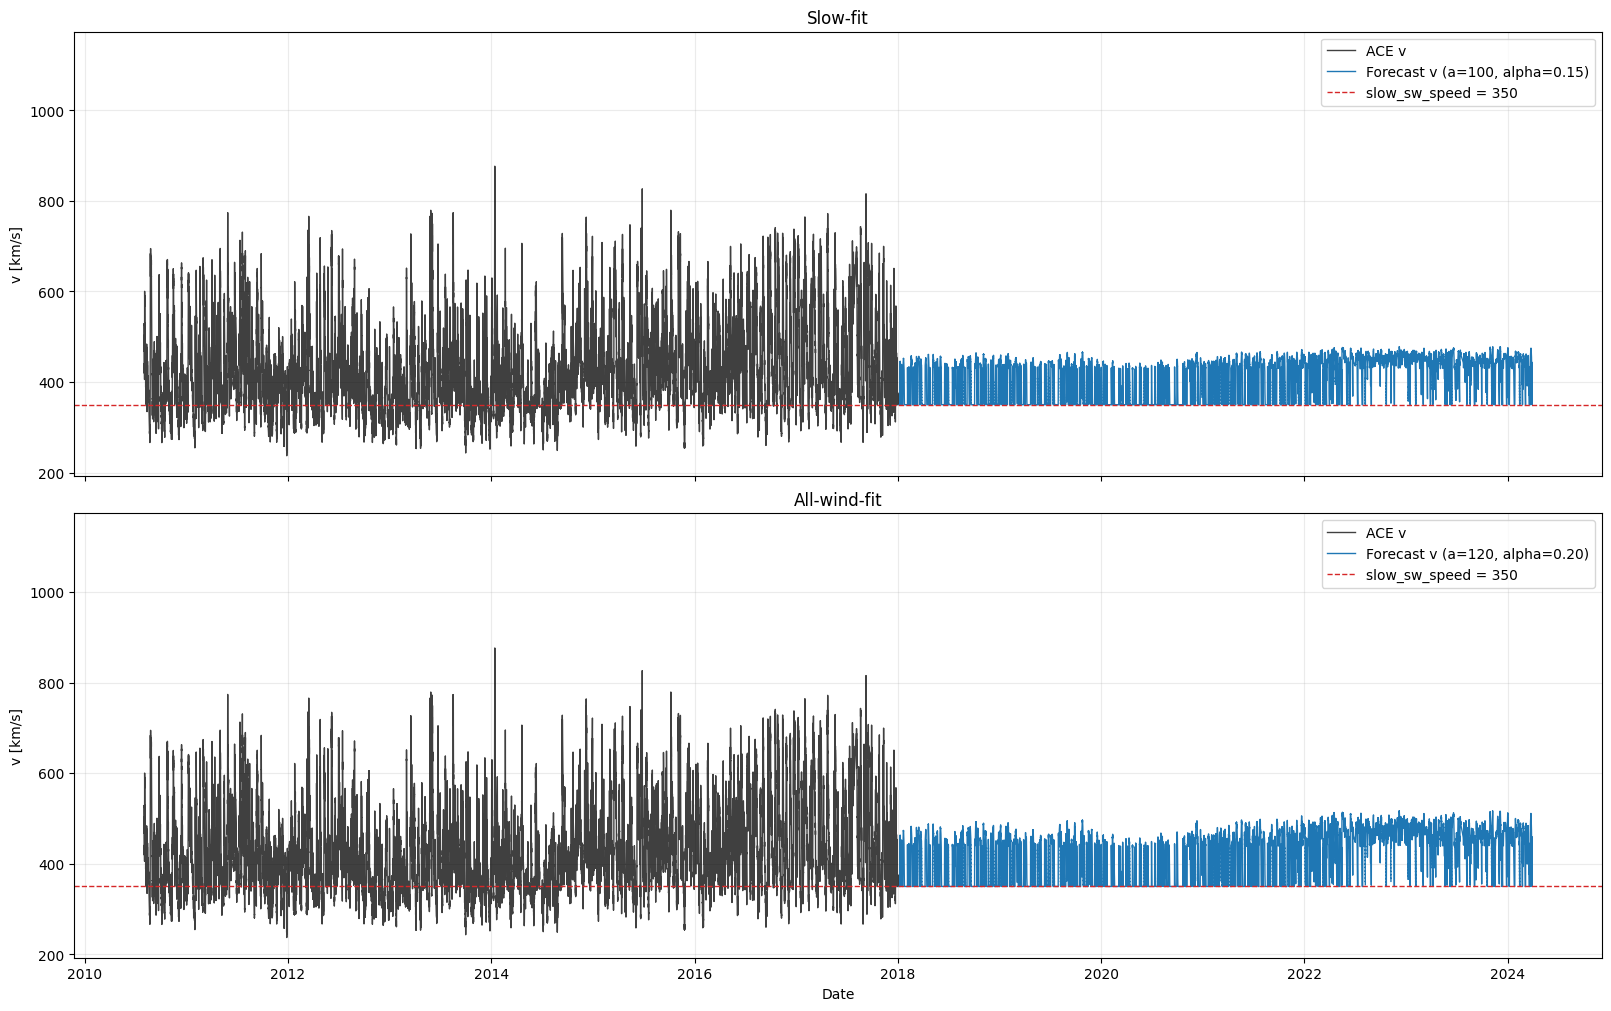

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True, constrained_layout=True)

plot_frames = [
    (axes[0], slow_fit_comparison, slow_fit_params),
    (axes[1], full_fit_comparison, full_fit_params),
]


for ax, frame, params in plot_frames:
    ax.plot(frame.index, frame["v_ace"], label="ACE v", color="black", linewidth=1.0, alpha=0.75)
    ax.plot(
        frame.index,
        frame["v_forecast"],
        label=f"Forecast v (a={params['a']:.0f}, alpha={params['alpha']:.2f})",
        color="tab:blue",
        linewidth=1.0,
    )
    ax.axhline(
        empirical_defaults.slow_sw_speed,
        color="tab:red",
        linestyle="--",
        linewidth=1.0,
        label=f"slow_sw_speed = {empirical_defaults.slow_sw_speed:.0f}",
    )
    ax.set_ylabel("v [km/s]")
    ax.set_title(params["label"])
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Date")
plt.show()